In [165]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [166]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

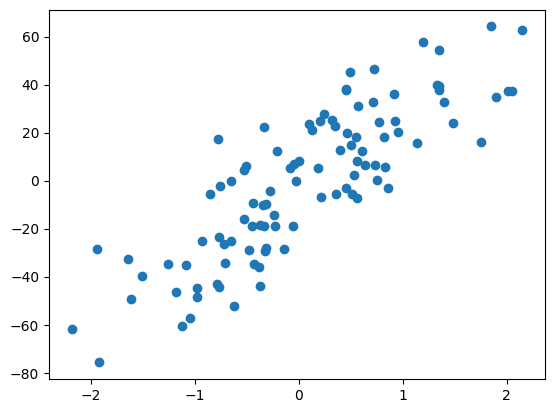

In [167]:
plt.scatter(X,y)

In [168]:
from sklearn.linear_model import LinearRegression

In [169]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)


[27.82809103]
-2.29474455867698


In [170]:
from sklearn.linear_model import Ridge

In [171]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [172]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


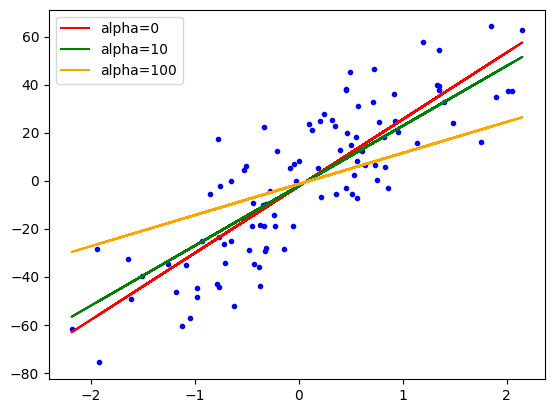

In [173]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [174]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()
    
    num = 0
    den = 0
    
    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)
        
    m = num/(den + alpha)
    b = y_mean - m*x_mean
        
    return m,b

In [175]:
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())
        
        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)
    
    def predict(X_test):
        pass

In [176]:
reg = MeraRidge(alpha=100)

In [177]:
reg.fit(X,y)

[12.93442104] [-1.42484415]


In [178]:
import numpy as np

# Simple random dataset
np.random.seed(0)
X = np.random.randn(100, 2)
y = np.random.randn(100)

In [179]:
m, n = X.shape
w = np.zeros(n)


In [180]:
m,n

(100, 2)

In [181]:
w

array([0., 0.])

In [182]:
# Normal Linear Regression
# w=(XTX)−1XTy
w_linear = np.linalg.inv(X.T @ X) @ X.T @ y #linalg.inv is used to find the inverse of a matrix

print("Linear Regression Weights:", w_linear)

Linear Regression Weights: [ 0.11034461 -0.06101577]


In [183]:
# lasso regression
learning_rate = 0.01
lambda_param = 0.5
iterations = 1000

In [184]:
for _ in range(iterations):
    
    y_pred = X @ w #@ sign is for matrix multiplication 
    
    # Gradient of MSE
    gradient = (1/m) * (X.T @ (y_pred - y))
    
    # Add L1 regularization term (Lasso part)
    gradient = gradient + lambda_param * np.sign(w)
    
    # Update weights
    w = w - learning_rate * gradient

print("Final weights:", w)

Final weights: [-0.00098545  0.00236612]


In [185]:
from sklearn.linear_model import Lasso

In [186]:
lasso_model = Lasso(alpha=0.5, fit_intercept=False)

In [187]:
lasso_model.fit(X, y)

Lasso(alpha=0.5, fit_intercept=False)

In [188]:
print("Sklearn Lasso Weights:", lasso_model.coef_)

Sklearn Lasso Weights: [ 0. -0.]


In [189]:
# Lasso used by sklearn 
m, n = X.shape # takes the no of  samples and no of features(columns)
w_lasso = np.zeros(n) # creates an initial 0 values of coefficients

lambda_param = 0.5 #Controls how strongly we shrink weights
                   # Bigger value → more shrinkage → more zeros
iterations = 100

for _ in range(iterations):
    for j in range(n):  # Go feature by feature
                        # First update w₀
                        # Then update w₁
                        # This is called Coordinate Descent
        
        y_pred = X @ w_lasso #Multiply input matrix with weights #@ is used for matrix multiplication
        
        residual = y - y_pred + w_lasso[j] * X[:, j] 
        # y - y_pred → error (actual − predicted)
        # w_lasso[j] * X[:, j] → add back contribution of feature j(like uss particular 
        # feature ne pehele kitna contribute kra)
        
        zj = (1/m) * np.dot(X[:, j], residual) 
        # Meaning:
        # How strongly feature j explains the remaining error.
        # Large positive zj → increase weight
        # Large negative zj → decrease weight
        # Small zj → weak feature
        
        if zj > lambda_param:
            w_lasso[j] = zj - lambda_param #If zj is strongly positive → shrink by λ
        elif zj < -lambda_param:
            w_lasso[j] = zj + lambda_param #If zj is strongly negative → shrink by λ
        else:
            w_lasso[j] = 0 #If zj is small → set weight to ZERO
        #This is why Lasso does feature selection.Small features get killed.

print("Lasso Weights:", w_lasso)

Lasso Weights: [0. 0.]


In [190]:
import numpy as np
np.random.seed(0)

m = 100

# Two features
X = np.random.randn(m, 2)

# Only first feature affects y
y = 5 * X[:, 0] + np.random.randn(m) * 0.5

In [191]:
lambda_param = 0.5
iterations = 200

In [192]:
for _ in range(iterations): 
    for j in range(n):
        y_pred = X @ w_lasso
        residual = y - y_pred + w_lasso[j] * X[:, j]
        zj = (1/m) * np.dot(X[:, j], residual)
        if zj > lambda_param: 
            w_lasso[j] = zj - lambda_param
        elif zj < -lambda_param:
            w_lasso[j] = zj + lambda_param 
        else:
           w_lasso[j] = 0 
    
    
print("Lasso Weights:", w_lasso)

Lasso Weights: [4.78038062 0.        ]


In [193]:
#elastic net regression

learning_rate = 0.01
lambda_l1 = 0.5   # Lasso part
lambda_l2 = 0.5   # Ridge part
iterations = 1000

for _ in range(iterations):
    
    y_pred = X @ w
    
    # MSE Gradient
    gradient = (1/m) * (X.T @ (y_pred - y))
    
    # Add L1 Gradient(lasso)
    gradient += lambda_l1 * np.sign(w)
    
    # Add L2 Gradient(ridge)
    gradient += 2 * lambda_l2 * w
    
    # Update weights
    w = w - learning_rate * gradient

print("Elastic Net Weights:", w)

Elastic Net Weights: [ 2.33828019e+00 -4.56516005e-05]
